In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
df = pd.read_csv("french_results.csv")

In [3]:
print("Variables :\n")
print(list(df.columns))

print("\nHead :\n")
print(df.head())

print("\nInfo :\n")
print(df.info())

Variables :

['speaker_id', 'username', 'predicted_id', 'predicted_username', 'score', 'correct', 'gender', 'age', 'dialect', 'micro_make', 'micro_type', 'sampling_rate']

Head :

  speaker_id username  predicted_id predicted_username     score  correct  \
0         4h       4h      20100505                 4h  0.731784     True   
1         4h       4h      20100505                 4h  0.715495     True   
2         4h       4h      20100505                 4h  0.773214     True   
3         4h       4h      20100505                 4h  0.753887     True   
4         4h       4h      20100505                 4h  0.645861     True   

     gender     age          dialect  micro_make    micro_type  sampling_rate  
0  Masculin  Adulte  Français Suisse         NaN  Casque micro          48000  
1  Masculin  Adulte  Français Suisse         NaN  Casque micro          48000  
2  Masculin  Adulte  Français Suisse         NaN  Casque micro          48000  
3  Masculin  Adulte  Français Suisse 

In [4]:
print("Valeurs manquantes")
print(df.isnull().sum())

# Supprimer la colonne micro_make
df = df.drop(columns=['micro_make'])

print(f"Shape après nettoyage : {df.shape}")

Valeurs manquantes
speaker_id                0
username                  0
predicted_id              0
predicted_username        0
score                     0
correct                   0
gender                    0
age                       0
dialect                   0
micro_make            23131
micro_type                0
sampling_rate             0
dtype: int64
Shape après nettoyage : (23131, 11)


In [5]:
# Colonnes catégorielles
for col in ['gender', 'age', 'dialect', 'micro_type']:
    df[col] = df[col].astype('category')

# Identifiants
df['speaker_id'] = df['speaker_id'].astype('string')
df['predicted_id'] = df['predicted_id'].astype('string')

# Username
df['username'] = df['username'].astype('string')
df['predicted_username'] = df['predicted_username'].astype('string')
df['username'] = df['username'].str.lower()
df['predicted_username'] = df['predicted_username'].str.lower()

# Enlever les anonymous
df = df[df["username"] != "anonymous"]

print(df.dtypes)

speaker_id            string[python]
username              string[python]
predicted_id          string[python]
predicted_username    string[python]
score                        float64
correct                         bool
gender                      category
age                         category
dialect                     category
micro_type                  category
sampling_rate                  int64
dtype: object


Les personnes sur lesquelles le modèle s'est trompé malgré une forte confiance

In [6]:
faux_haute_confiance = df[
    (df['correct'] == False) & 
    (df['score'] > 0.8)
][['username', 'predicted_username', 'score']].sort_values('score', ascending=False)

print(faux_haute_confiance)

                           username            predicted_username     score
11071                      francois                       franois  0.841543
11458                       franois                      francois  0.834962
19323                  samuelbuffet                     anonymous  0.833584
6669   cedricvasseuraliasbeepmaster   cdricvasseuraliasbeepmaster  0.832308
11449                       franois                      francois  0.828423
4762                          arbae                     rabea2008  0.826586
6694   cedricvasseuraliasbeepmaster   cdricvasseuraliasbeepmaster  0.825507
20185                  samuelbuffet                     anonymous  0.825361
17143                         phils                        phil_s  0.821754
11053                      francois                       franois  0.820455
6704   cedricvasseuraliasbeepmaster  cedricvasseuraliasbeepmaster  0.817564
19319                  samuelbuffet                     anonymous  0.814417
4620        

Certaines personnes ont juste un pseudo légèrement différent donc ce sont les mêmes personnes en réalité. On nettoie ça

In [14]:
mapping = {
    'franois': 'francois',
    'cdricvasseuraliasbeepmaster': 'cedricvasseuraliasbeepmaster',
    'rabea2008': 'arbae',
    'phil_s': 'phils',
    'jpquantin': 'jpquanti',
    'lebourgphilippe4':'lebourgphilippe',
    'colinecarreremsncom':'colinecarrere',
    'thvenin':'thevenin'
}

df['username'] = df['username'].replace(mapping)
df['predicted_username'] = df['predicted_username'].replace(mapping)

#on change cet anonymous en samuelbuffet après vérification dans le dataset, pareil pour garous/agoniste
df.loc[(df['username'] == 'anonymous') & (df['speaker_id'] == '20080912'), 'username'] = 'samuelbuffet'
df.loc[(df['predicted_username'] == 'anonymous') & (df['predicted_id'] == '20080912'), 'predicted_username'] = 'samuelbuffet'
df.loc[df['username'] == 'agoniste', 'username'] = 'garous'
df.loc[df['predicted_username'] == 'agoniste', 'predicted_username'] = 'garous'

df['correct'] = df['username'] == df['predicted_username']

In [23]:
faux_haute_confiance = df[
    (df['correct'] == False) & 
    (df['score'] > 0.6)
][['username', 'predicted_username','score']].sort_values('score', ascending=False)

print(faux_haute_confiance)

               username            predicted_username     score
14169   libertairebesac                    jobesancon  0.780616
22868       wwwdarnoxfr                         lucas  0.766692
13325        jobesancon               libertairebesac  0.763136
6443              benot                           ben  0.762711
15061             lucas                   wwwdarnoxfr  0.761629
...                 ...                           ...       ...
21071           thierry                      thierryb  0.600954
5447              arbae  cedricvasseuraliasbeepmaster  0.600540
12118  gonzalezjeanmarc            jeanmarc_cortiella  0.600353
6759             choco7                          olge  0.600233
4983              arbae                        trimss  0.600073

[311 rows x 3 columns]


# Performance globale

Accuracy globale

In [16]:
print(f"Accuracy globale : {df['correct'].mean():.2%}")
print(f"Total prédictions : {len(df)}")

Accuracy globale : 90.33%
Total prédictions : 19149


Distribution des scores

In [17]:
print(df.groupby('correct')['score'].describe())

           count      mean       std       min       25%       50%       75%  \
correct                                                                        
False     1851.0  0.537828  0.071543  0.273813  0.488053  0.527679  0.574446   
True     17298.0  0.664248  0.082083  0.349740  0.608289  0.669955  0.724438   

              max  
correct            
False    0.780616  
True     0.997951  


Seuil de décision optimal
Il faut maximiser le True Positive Rate et minimiser le False Positive Rate. On utilise la courbe ROC (Receiver Operating Characteristic). AUC = Area Under the Curve

In [20]:
fpr, tpr, thresholds = roc_curve(df['correct'], df['score'])
auc = roc_auc_score(df['correct'], df['score'])

# Seuil optimal
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

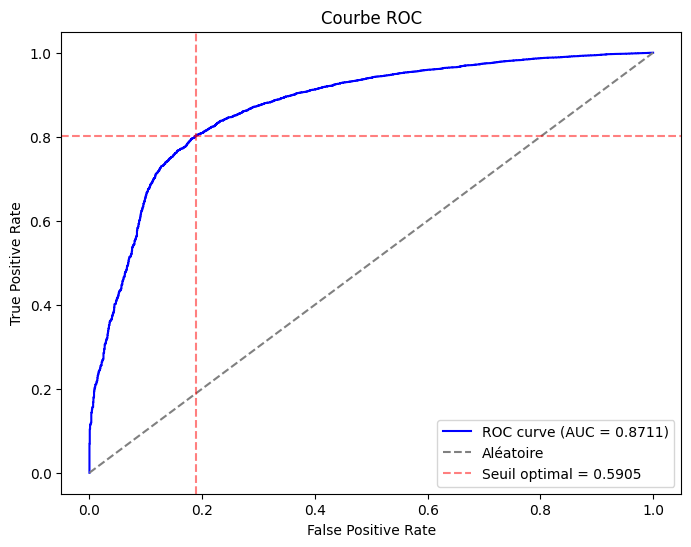

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aléatoire')
plt.axvline(x=fpr[optimal_idx], color='red', linestyle='--', alpha=0.5)
plt.axhline(y=tpr[optimal_idx], color='red', linestyle='--', alpha=0.5, label=f'Seuil optimal = {optimal_threshold:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

In [22]:
print(f"AUC : {auc:.4f}")
print(f"Seuil optimal : {optimal_threshold:.4f}")

AUC : 0.8711
Seuil optimal : 0.5905


Avec un seuil de 0.59, le modèle accepte correctement 80% des voix et en rejette 20% à tord. Il rejette 81% des voix correctement et accepte 19% par erreur.

# Biais et équité

C:\Users\PC5\AppData\Local\Temp\ipykernel_17828\2981747152.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = temp.groupby(col)['correct'].mean().sort_values()
C:\Users\PC5\AppData\Local\Temp\ipykernel_17828\2981747152.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = temp.groupby(col)['correct'].mean().sort_values()
C:\Users\PC5\AppData\Local\Temp\ipykernel_17828\2981747152.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and s

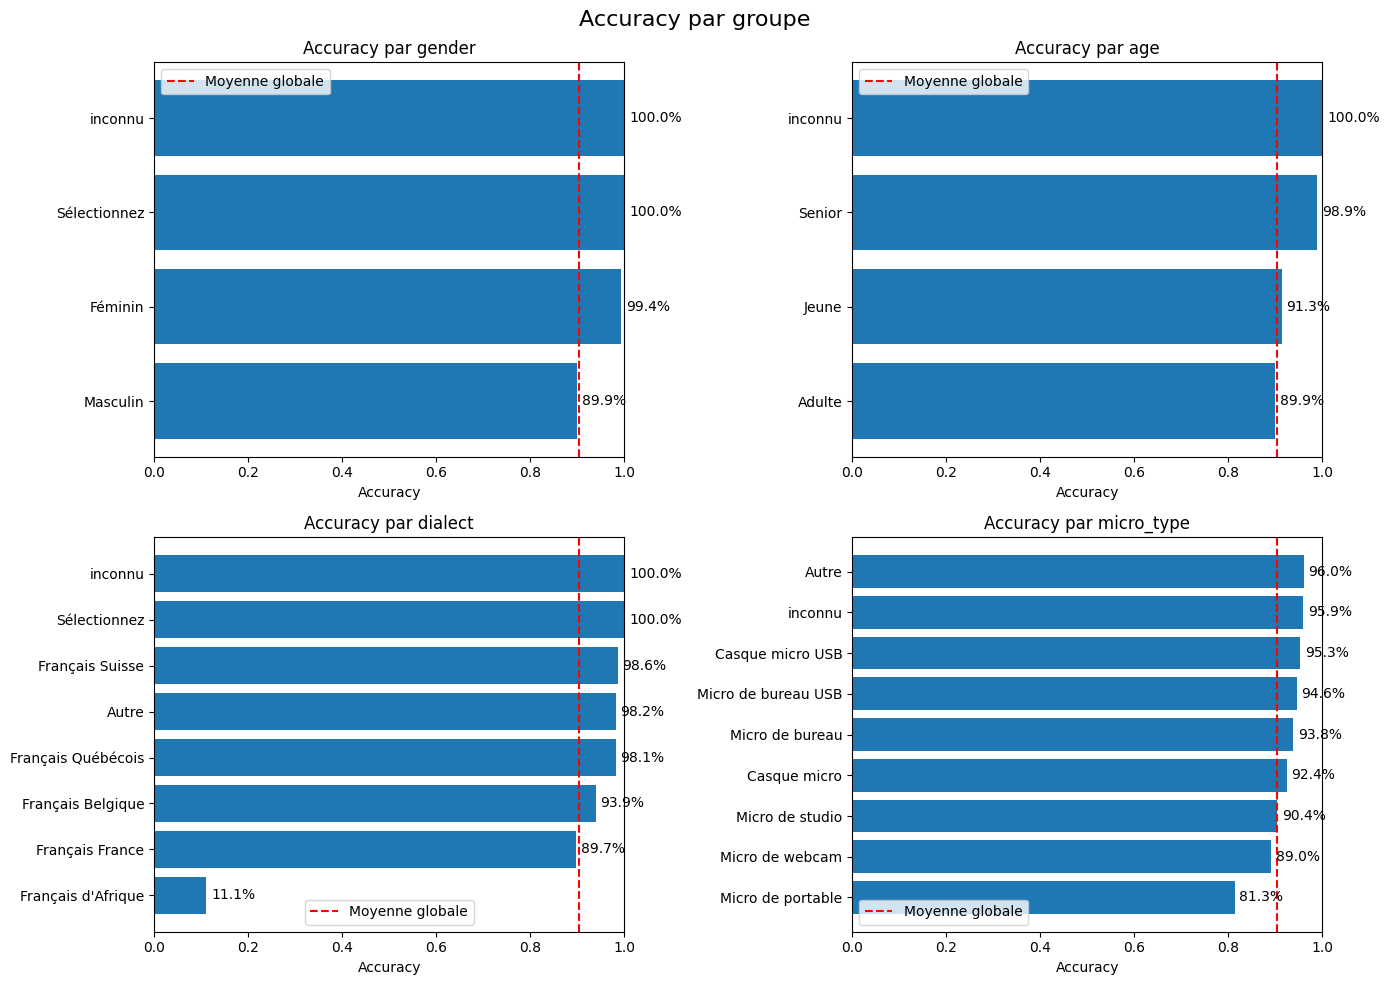

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Accuracy par groupe", fontsize=16)

for ax, col in zip(axes.flatten(), ['gender', 'age', 'dialect', 'micro_type']):
    temp = df.dropna(subset=[col]).copy()
    temp['correct'] = temp['correct'].astype(bool)
    data = temp.groupby(col)['correct'].mean().sort_values()
    bars = ax.barh(data.index.astype(str), data.values.astype(float))
    ax.set_xlim(0, 1)
    ax.set_title(f"Accuracy par {col}")
    ax.set_xlabel("Accuracy")
    ax.axvline(x=df['correct'].astype(bool).mean(), color='red', linestyle='--', label='Moyenne globale')
    ax.legend()
    
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center')

plt.tight_layout()
plt.show()

Accuracy par genre

Accuracy par âge

Accuracy par dialecte

Accuracy par type de micro

# Performance par speaker

Speakers les mieux reconnus

Speakers les moins bien reconnus

Nombre de tests par speaker

# Analyse des erreurs

Faux positifs à haute confiance

Paires de speakers souvent confondus entre eux

Est-ce que le modèle confond toujours les mêmes personnes ?

# Seuil de décision
À quel score faut-il dire "je ne sais pas qui c'est" plutôt que de se tromper ?
A tester si on a des gens présents et des gens pas présents dans qdrant.